# Experiment 1: Simple Linear Regression
Predicting 'Sales' using 'TV' marketing budget.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# a) Importing data and understanding its structure
url_tv = "https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv"
df_tv = pd.read_csv(url_tv)
print("Data Head:\n", df_tv.head())
print("\nData Info:")
df_tv.info()
print("\nData Description:\n", df_tv.describe())

Data Head:
       TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

Data Description:
                TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


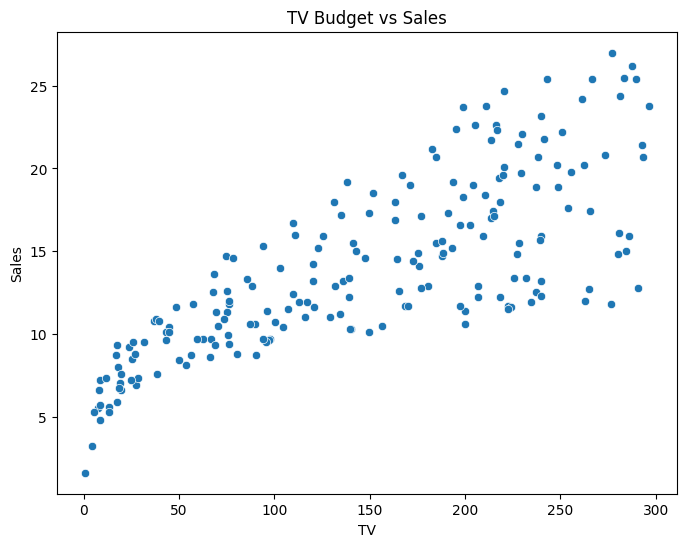

In [2]:
# b) Visualising Data Using Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_tv, x='TV', y='Sales')
plt.title('TV Budget vs Sales')
plt.show()

In [3]:
# c) Splitting Data into Training and Testing Sets (80:20)
X = df_tv[['TV']]
y = df_tv['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (160, 1)
Testing set shape: (40, 1)


Optimal Model Parameters:
Intercept (b0): 7.119638430592953
Coefficient (b1): 0.046529733705443346


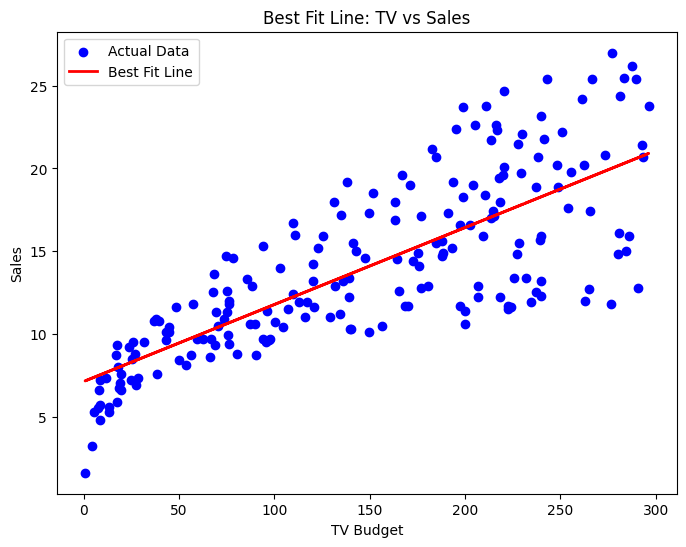

In [4]:
# d) Train a Simple Linear regression Model (y = b0 + b1 * X)
model_tv = LinearRegression()
model_tv.fit(X_train, y_train)

print("Optimal Model Parameters:")
print("Intercept (b0):", model_tv.intercept_)
print("Coefficient (b1):", model_tv.coef_[0])

# Visualised the best fit line
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model_tv.predict(X), color='red', linewidth=2, label='Best Fit Line')
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.legend()
plt.title('Best Fit Line: TV vs Sales')
plt.show()

In [5]:
# e) Display actual vs predicted sales
y_pred_tv = model_tv.predict(X_test)
comparison_tv = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_tv})
print("Actual vs Predicted Sales (First 10 rows):\n", comparison_tv.head(10))

Actual vs Predicted Sales (First 10 rows):
      Actual  Predicted
95     16.9  14.717944
15     22.4  16.211548
30     21.4  20.748197
158     7.3   7.664036
128    24.7  17.370139
115    12.6  10.614021
69     22.3  17.207285
170     8.4   9.446125
174    11.5  17.467851
45     14.9  15.266995


In [6]:
# f) Computing RMSE and R2 Values
rmse_tv = np.sqrt(mean_squared_error(y_test, y_pred_tv))
r2_tv = r2_score(y_test, y_pred_tv)
print("RMSE:", rmse_tv)
print("R2 Value:", r2_tv)

RMSE: 3.194472431998898
R2 Value: 0.6766954295627076


# Experiment 2: Multiple Linear Regression
Predicting 'CO2' based on 'VOLUME' and 'WEIGHT'.

In [7]:
# a) Importing data and understanding its structure
# Using a raw link for the CO2 dataset that matches the features (Volume, Weight, CO2)
url_co2 = "https://www.w3schools.com/python/data.csv"
df_co2 = pd.read_csv(url_co2)
print("Data Head:\n", df_co2.head())
print("\nData Info:")
df_co2.info()

Data Head:
           Car       Model  Volume  Weight  CO2
0      Toyoty        Aygo    1000     790   99
1  Mitsubishi  Space Star    1200    1160   95
2       Skoda      Citigo    1000     929   95
3        Fiat         500     900     865   90
4        Mini      Cooper    1500    1140  105

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     36 non-null     object
 1   Model   36 non-null     object
 2   Volume  36 non-null     int64 
 3   Weight  36 non-null     int64 
 4   CO2     36 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 1.5+ KB


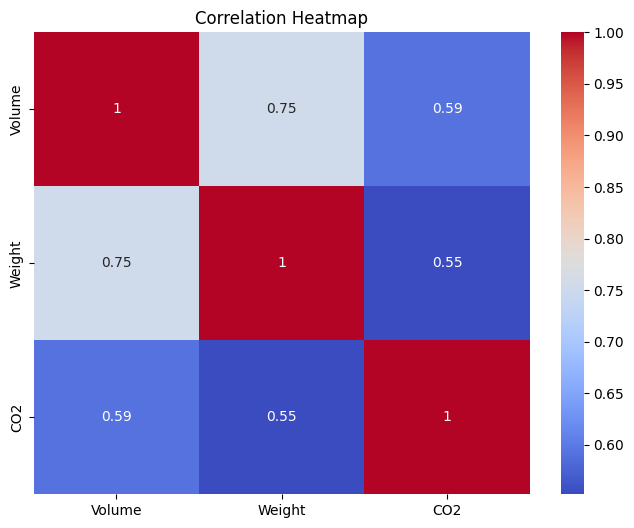

In [8]:
# b) Calculate the co-relation co-efficient and display a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_co2[['Volume', 'Weight', 'CO2']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

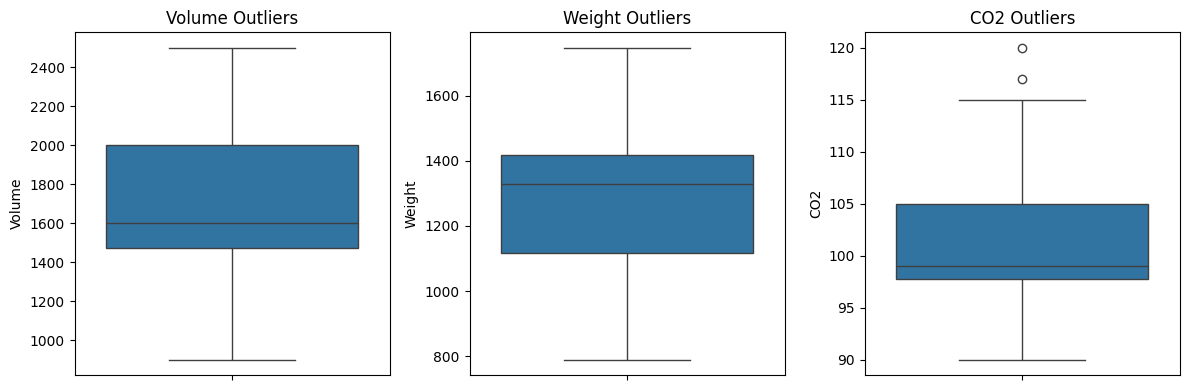

In [9]:
# c) Check and display the possible outliers in volume, weight and CO2 features (Use box plot)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.boxplot(y=df_co2['Volume'])
plt.title('Volume Outliers')

plt.subplot(1,3,2)
sns.boxplot(y=df_co2['Weight'])
plt.title('Weight Outliers')

plt.subplot(1,3,3)
sns.boxplot(y=df_co2['CO2'])
plt.title('CO2 Outliers')

plt.tight_layout()
plt.show()

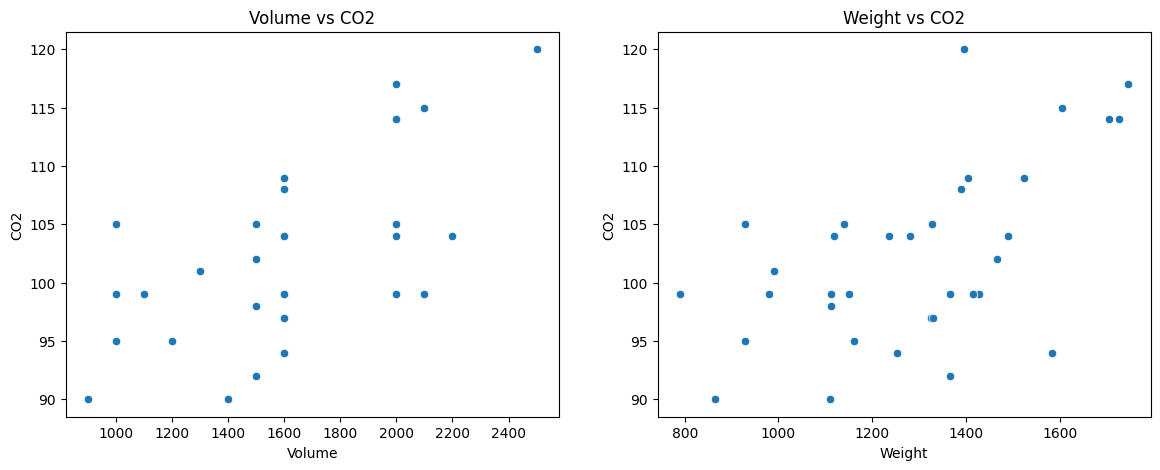

In [10]:
# d) Visualize the relation of CO2 with other two features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df_co2, x='Volume', y='CO2', ax=ax1)
ax1.set_title('Volume vs CO2')
sns.scatterplot(data=df_co2, x='Weight', y='CO2', ax=ax2)
ax2.set_title('Weight vs CO2')
plt.show()

In [11]:
# e) Train a multiple linear regression model (take train-test split as 80:20)
X_multi = df_co2[['Volume', 'Weight']]
y_multi = df_co2['CO2']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
print("Model Trained Successfully.")

Model Trained Successfully.


Intercept: 84.21502006695282
Weights (Volume, Weight): [0.00428741 0.00804928]


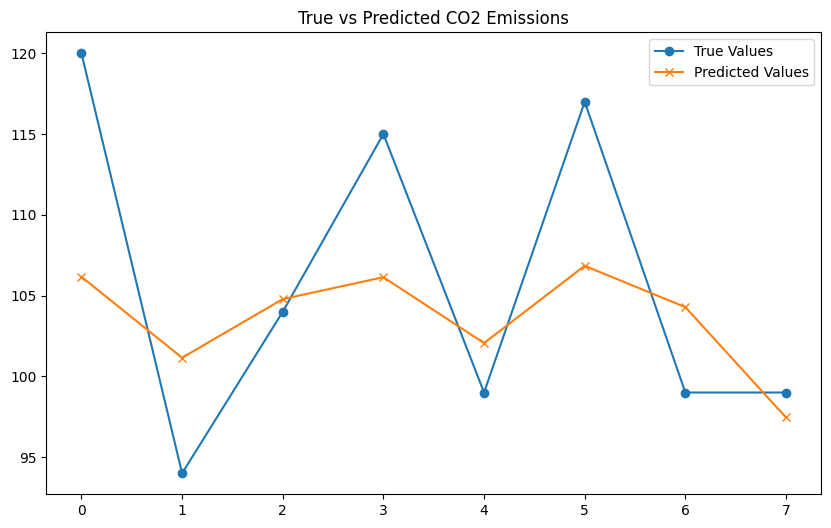

In [12]:
# f) Calculate weight and intercept. Visualized the true vs predicted outcome
print("Intercept:", model_multi.intercept_)
print("Weights (Volume, Weight):", model_multi.coef_)

y_pred_m = model_multi.predict(X_test_m)
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test_m)), y_test_m.values, label='True Values', marker='o')
plt.plot(range(len(y_pred_m)), y_pred_m, label='Predicted Values', marker='x')
plt.title('True vs Predicted CO2 Emissions')
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error
# g) Calculate and display Mean Absolute Error, Mean Square Error, and Root Mean Square Error
mae = mean_absolute_error(y_test_m, y_pred_m)
mse = mean_squared_error(y_test_m, y_pred_m)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Square Error (MSE):", mse)
print("Root Mean Square Error (RMSE):", rmse)

Mean Absolute Error (MAE): 6.335639624274503
Mean Square Error (MSE): 58.07928583657771
Root Mean Square Error (RMSE): 7.620976698335832


# Experiment 3: Logistic Regression
Predicting advertisement clicks.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# a) Load and display the information about the dataset
url_ads = "https://raw.githubusercontent.com/shubham13p/Ad-Click-Prediction/master/advertising.csv"
df_ads = pd.read_csv(url_ads)
print("Data Info:")
df_ads.info()
print("\nMissing Values:\n", df_ads.isnull().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB

Missing Values:
 Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line         

In [15]:
# b) Apply Exploratory data analysis (Missing value treatment, Transformation and normalization)
# Handling missing values (if any)
df_ads.fillna(df_ads.mean(numeric_only=True), inplace=True)

# Data transformation: Selecting relevant numeric features for the model
X_ads = df_ads[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]
y_ads = df_ads['Clicked on Ad']

# Normalization (Standardization)
scaler = StandardScaler()
X_ads_scaled = scaler.fit_transform(X_ads)
print("Data Transformation and Normalization completed.")

Data Transformation and Normalization completed.


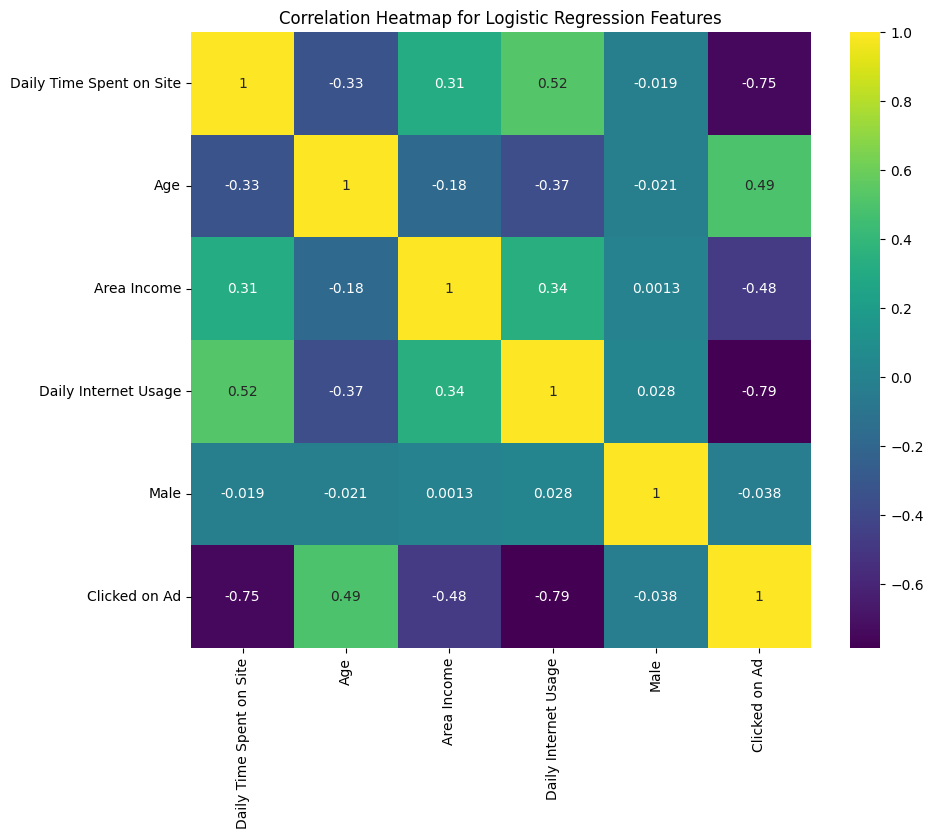

In [16]:
# c) Find co-relation among the features and display the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pd.concat([pd.DataFrame(X_ads_scaled, columns=X_ads.columns), y_ads], axis=1).corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap for Logistic Regression Features')
plt.show()

In [17]:
# d) Train a logistic regression model and calculate parameters (80:20 split)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_ads_scaled, y_ads, test_size=0.2, random_state=42)
log_model = LogisticRegression()
log_model.fit(X_train_a, y_train_a)

print("Model Intercept:", log_model.intercept_)
print("Model Coefficients:", log_model.coef_)

Model Intercept: [1.47571247]
Model Coefficients: [[-2.52553311  1.25056071 -1.63704805 -2.70402918 -0.35862744]]


In [18]:
# e) Apply K-fold cross validation split
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(log_model, X_ads_scaled, y_ads, cv=kf)
print("K-Fold Cross Validation Results (Accuracy):", cv_results)
print("Mean Accuracy:", cv_results.mean())

K-Fold Cross Validation Results (Accuracy): [0.96  0.98  0.985 0.96  0.97 ]
Mean Accuracy: 0.9709999999999999


In [19]:
# f) Display the classification report (Precision, recall and F1-score)
y_pred_a = log_model.predict(X_test_a)
print("Classification Report:\n", classification_report(y_test_a, y_pred_a))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        89
           1       0.97      0.95      0.96       111

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



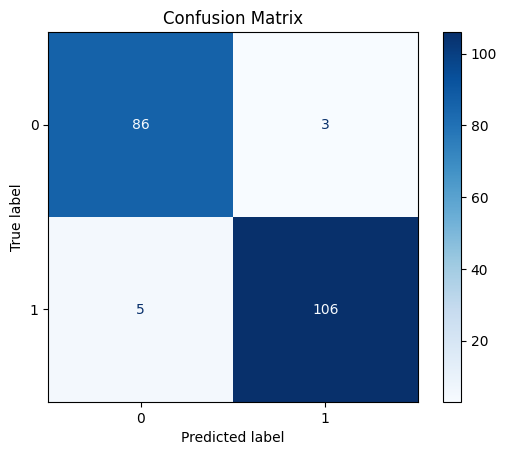

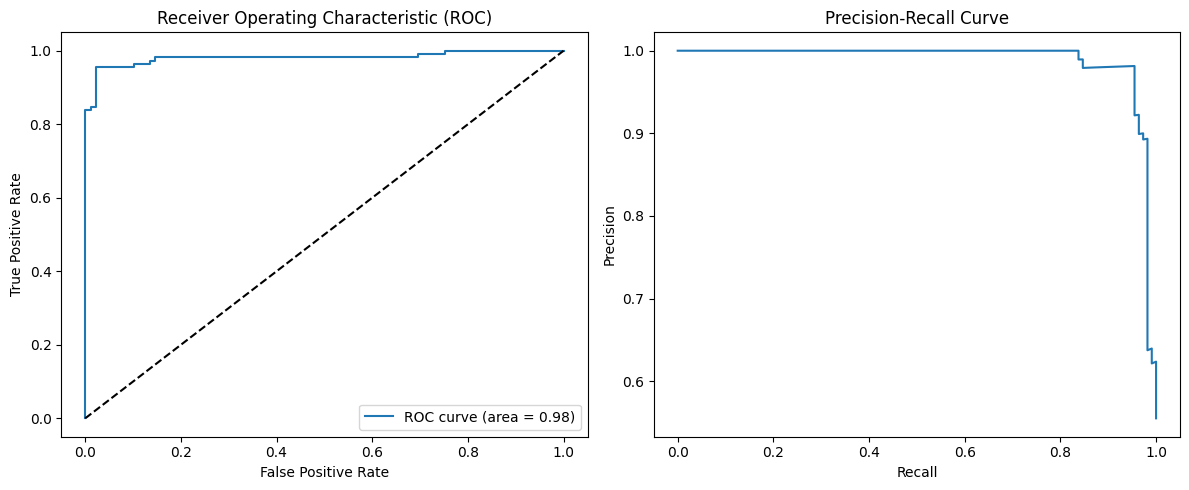

In [20]:
# g) Display the confusion matrix and ROC curve, Precision Recall curve
# Confusion Matrix
cm = confusion_matrix(y_test_a, y_pred_a)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
y_probs = log_model.predict_proba(X_test_a)[:, 1]
fpr, tpr, _ = roc_curve(y_test_a, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_a, y_probs)
plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

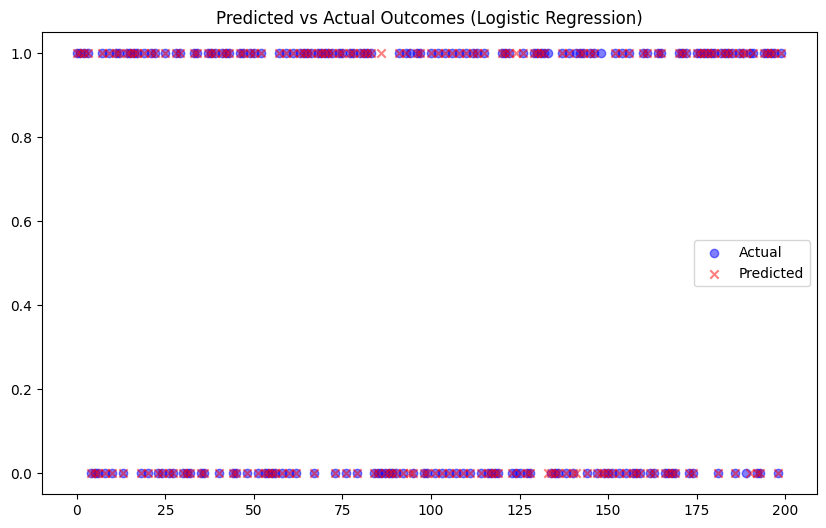

In [21]:
# h) Visualised the predicted vs actual outcome
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test_a)), y_test_a, color='blue', label='Actual', alpha=0.5, marker='o')
plt.scatter(range(len(y_pred_a)), y_pred_a, color='red', label='Predicted', alpha=0.5, marker='x')
plt.title('Predicted vs Actual Outcomes (Logistic Regression)')
plt.legend()
plt.show()